# 🎬 Movie Recommendation System

## Project Overview
In this project, we will build a Movie Recommendation System
using Content-Based Filtering and Collaborative Filtering.

### Dataset:
- MovieLens Small Dataset (GroupLens)
- 9000+ Movies
- 100,000+ Ratings
- 600+ Users

### Techniques Used:
- Content-Based Filtering (TF-IDF + Cosine Similarity)
- Collaborative Filtering (SVD)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
# Load Dataset
movies = pd.read_csv('movies.csv')
ratings = pd.read_csv('ratings.csv')

print("Movies shape:", movies.shape)
print("Ratings shape:", ratings.shape)

print("\nMovies head:")
movies.head()

Movies shape: (9742, 3)
Ratings shape: (100836, 4)

Movies head:


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [3]:
print("\nRatings head:")
ratings.head()


Ratings head:


,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [4]:
# Basic Info
print(movies.info())
print("\n")
print(ratings.info())

<class 'pandas.DataFrame'>
RangeIndex: 9742 entries, 0 to 9741
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   movieId  9742 non-null   int64
 1   title    9742 non-null   str  
 2   genres   9742 non-null   str  
dtypes: int64(1), str(2)
memory usage: 228.5 KB
None


<class 'pandas.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100836 non-null  int64  
 1   movieId    100836 non-null  int64  
 2   rating     100836 non-null  float64
 3   timestamp  100836 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.1 MB
None


In [5]:
# Null values check
print("Movies null values:")
print(movies.isnull().sum())

print("\nRatings null values:")
print(ratings.isnull().sum())

# Duplicate values check
print("\nMovies duplicates:", movies.duplicated().sum())
print("Ratings duplicates:", ratings.duplicated().sum())

Movies null values:
movieId    0
title      0
genres     0
dtype: int64

Ratings null values:
userId       0
movieId      0
rating       0
timestamp    0
dtype: int64

Movies duplicates: 0
Ratings duplicates: 0


In [6]:
# ================================
# Basic EDA
# ================================
print("Movies Dataset Info:")
print(f"Total Movies: {movies.shape[0]}")
print(f"Total Ratings: {ratings.shape[0]}")
print(f"Total Users: {ratings['userId'].nunique()}")
print(f"Average Rating: {ratings['rating'].mean():.2f}")

Movies Dataset Info:
Total Movies: 9742
Total Ratings: 100836
Total Users: 610
Average Rating: 3.50


In [7]:
print(f"Average users rating:- {100836 / 610:.2f}")

Average users rating:- 165.30


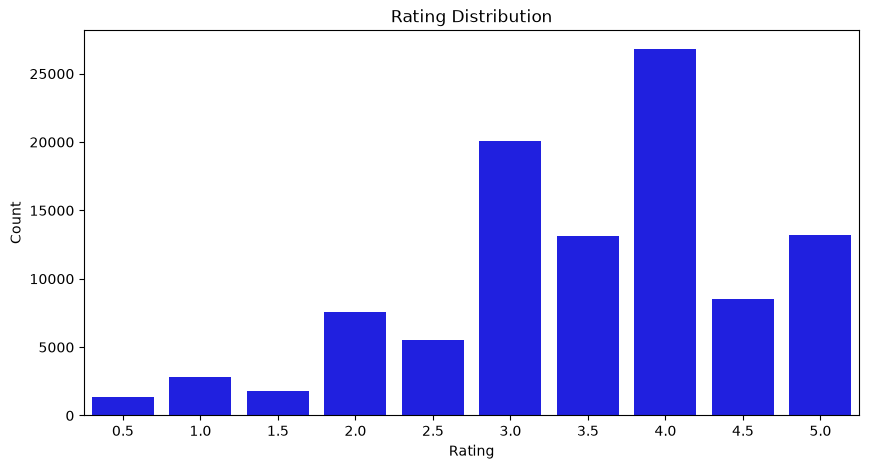

In [8]:
# Rating Distribution
plt.figure(figsize=(10, 5))
sns.countplot(x='rating', data=ratings, color='blue')
plt.title('Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

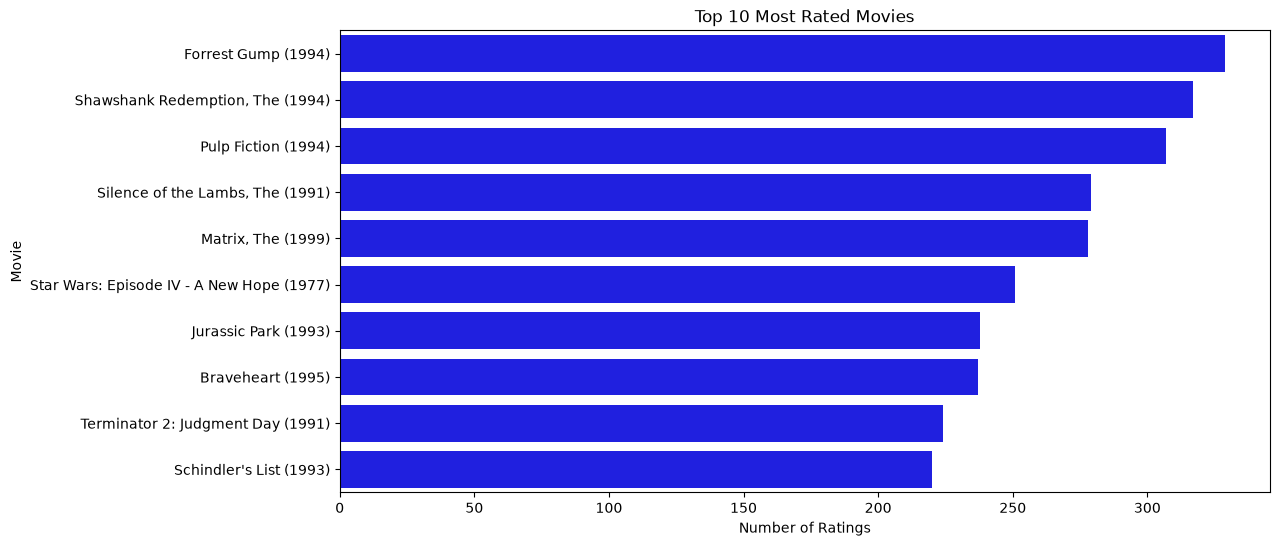

In [9]:
# Top 10 Most Rated Movies
top_movies = ratings.groupby('movieId')['rating'].count().sort_values(ascending=False).head(10)
top_movies = top_movies.reset_index()
top_movies = top_movies.merge(movies[['movieId', 'title']], on='movieId')

plt.figure(figsize=(12, 6))
sns.barplot(x='rating', y='title', data=top_movies, color='blue')
plt.title('Top 10 Most Rated Movies')
plt.xlabel('Number of Ratings')
plt.ylabel('Movie')
plt.show()

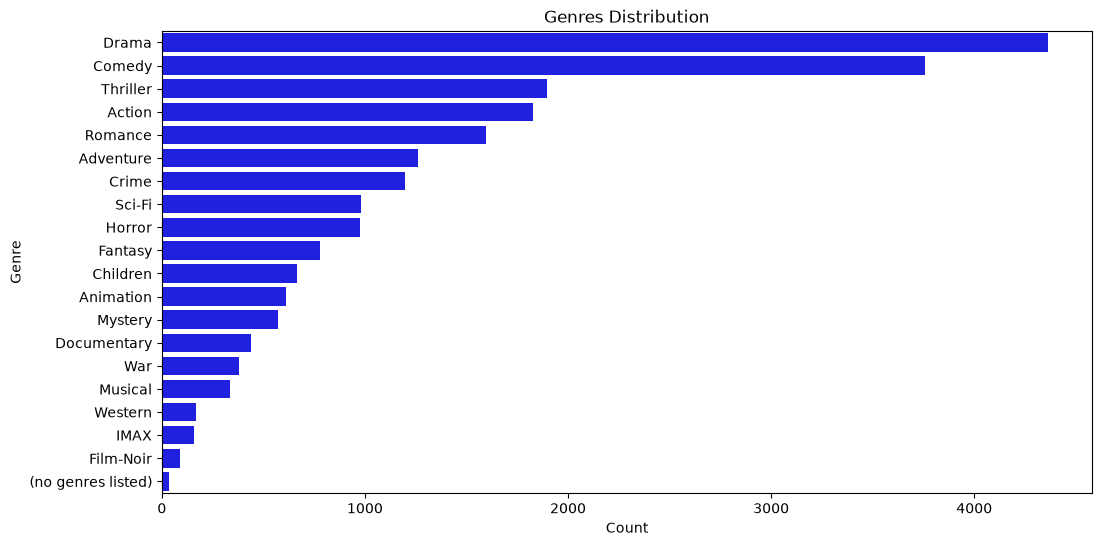

In [10]:
# Genres Distribution
all_genres = movies['genres'].str.split('|').explode()

plt.figure(figsize=(12, 6))
sns.countplot(y=all_genres, 
              order=all_genres.value_counts().index,
              color='blue')
plt.title('Genres Distribution')
plt.xlabel('Count')
plt.ylabel('Genre')
plt.show()

In [11]:

# Content Based Filtering

# Step 1 — Clean Genres
movies['genres'] = movies['genres'].str.replace('|', ' ')

# Step 2 — TF-IDF apply
tfidf = TfidfVectorizer()
tfidf_matrix = tfidf.fit_transform(movies['genres'])

print("TF-IDF Matrix Shape:", tfidf_matrix.shape)

TF-IDF Matrix Shape: (9742, 24)


In [12]:
# Step 3 — Calculate Cosine Similarity 
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)
print("Cosine Similarity Matrix Shape:", cosine_sim.shape)

Cosine Similarity Matrix Shape: (9742, 9742)


In [13]:
# Step 4 — Recommendation Function
indices = pd.Series(movies.index, index=movies['title'])

def get_recommendations(title, n=10):
    idx = indices[title]
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:n+1]
    movie_indices = [i[0] for i in sim_scores]
    return movies['title'].iloc[movie_indices]

In [14]:
# Test 
print("Movies similar to Toy Story:")
print(get_recommendations('Toy Story (1995)'))

Movies similar to Toy Story:
1706                                          Antz (1998)
2355                                   Toy Story 2 (1999)
2809       Adventures of Rocky and Bullwinkle, The (2000)
3000                     Emperor's New Groove, The (2000)
3568                                Monsters, Inc. (2001)
6194                                     Wild, The (2006)
6486                               Shrek the Third (2007)
6948                       Tale of Despereaux, The (2008)
7760    Asterix and the Vikings (Astérix et les Viking...
8219                                         Turbo (2013)
Name: title, dtype: str


In [15]:

# Collaborative Filtering

from surprise import SVD, Dataset, Reader
from surprise.model_selection import cross_validate, train_test_split
from surprise import accuracy

print("Surprise library imported successfully!")

Surprise library imported successfully!


In [ ]:
# Reader — rating scale 0.5 to 5.0
reader = Reader(rating_scale=(0.5, 5.0))

# Data load 
data = Dataset.load_from_df(ratings[['userId', 'movieId', 'rating']], reader)

print("Data loaded successfully! ")


Data loaded successfully! 


In [17]:

# Train Test Split & SVD Model


# Train Test Split
trainset, testset = train_test_split(data, test_size=0.2, random_state=42)

# SVD Model
svd_model = SVD(n_factors=100, n_epochs=20, random_state=42)

# Train model
svd_model.fit(trainset)

print("Model trained successfully! ")

Model trained successfully! 


In [18]:

# Model Evaluation


# Predictions 
predictions = svd_model.test(testset)

# RMSE and MAE 
print("SVD Model Results:")
rmse = accuracy.rmse(predictions, verbose=False)
mae = accuracy.mae(predictions, verbose=False)
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")

SVD Model Results:
RMSE: 0.8807
MAE: 0.6766


In [19]:
def get_svd_recommendations(user_id, n=10):
    watched_movies = ratings[ratings['userId'] == user_id]['movieId'].tolist()
    unwatched = movies[~movies['movieId'].isin(watched_movies)]
    
    unwatched = unwatched.copy()
    unwatched['predicted_rating'] = unwatched['movieId'].apply(
        lambda x: svd_model.predict(user_id, x).est
    )
    
    # Sort and round
    result = unwatched.nlargest(n, 'predicted_rating')[['title', 'predicted_rating']]
    result['predicted_rating'] = result['predicted_rating'].round(2)
    return result

print("Top 10 movies for User 1:")
print(get_svd_recommendations(1))


Top 10 movies for User 1:
                                                 title  predicted_rating
474                                Blade Runner (1982)               5.0
596         Ghost in the Shell (Kôkaku kidôtai) (1995)               5.0
602  Dr. Strangelove or: How I Learned to Stop Worr...               5.0
690                          North by Northwest (1959)               5.0
694                                  Casablanca (1942)               5.0
841                   Streetcar Named Desire, A (1951)               5.0
878     Cinema Paradiso (Nuovo cinema Paradiso) (1989)               5.0
896             One Flew Over the Cuckoo's Nest (1975)               5.0
906                          Lawrence of Arabia (1962)               5.0
924    Grand Day Out with Wallace and Gromit, A (1989)               5.0


In [20]:
print("Top 10 movies for User 2:")
print(get_svd_recommendations(2))

Top 10 movies for User 2:
                                                  title  predicted_rating
2582                Guess Who's Coming to Dinner (1967)              4.44
909                               Apocalypse Now (1979)              4.43
2462                        Boondock Saints, The (2000)              4.43
946                                Graduate, The (1967)              4.42
694                                   Casablanca (1942)              4.42
680                      Philadelphia Story, The (1940)              4.41
2743  For a Few Dollars More (Per qualche dollaro in...              4.40
659                               Godfather, The (1972)              4.40
602   Dr. Strangelove or: How I Learned to Stop Worr...              4.40
5335                           Shaun of the Dead (2004)              4.39
